In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv('/Users/maria/Desktop/Code/HSE/MACRO/дз_2/data - Лист1.csv')
df

,Year,Import,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
0,1992,75.33,36673.91,15.84,5.75,17671000.0,100.00,203480.54,26573.71,70262.00,4.27,18604.72,-5.30,207.42,60.61,24994401.00,15.45,444.00,66.89,0.0,21.97,8.66,0
1,1993,46.74,36673.91,15.84,4.74,13128900.0,1271.40,203480.54,26573.71,72918.00,4.27,711.00,-9.20,207.42,60.61,22651499.00,12.00,408.00,66.89,0.0,21.97,8.66,0
2,1994,47.12,36673.91,15.84,3.18,10520000.0,659.70,203480.54,2637.00,80441.00,4.27,1216.00,-12.60,35.54,60.61,26181682.00,5.50,415.00,66.89,0.0,21.97,8.66,0
3,1995,43.55,3038.00,15.84,4.19,14902200.0,964.26,203480.54,2806.00,95686.00,4.27,1660.00,-8.20,60.95,24.99,20969975.00,2.50,414.00,66.89,0.0,21.97,8.66,0
4,1996,36.00,4008.00,15.84,4.63,12975100.0,1136.88,203480.54,2781.00,42208.00,4.27,1960.00,0.50,67.30,32.94,21071975.00,1.73,457.00,66.89,0.0,21.97,8.66,0
5,1997,37.44,3560.00,15.84,5.75,13132600.0,1321.91,203480.54,2986.00,59005.00,4.27,2223.00,1.70,75.44,34.16,25079970.00,0.00,521.00,66.89,0.0,21.97,8.66,0
6,1998,34.86,3354.00,15.84,5.63,9335800.0,1160.89,203480.54,4026.00,90091.00,4.27,1965.00,-1.90,78.30,36.70,23402972.00,0.13,526.00,66.89,0.0,21.97,8.66,0
7,1999,40.12,2313.00,15.84,7.15,9616700.0,1437.69,203480.54,2959.00,121177.00,4.27,2001.00,2.70,119.52,43.64,17097980.00,0.08,604.00,66.89,0.0,21.97,8.66,0
8,2000,49.10,3873.00,15.84,8.18,16156800.0,1282.52,72276.00,3998.00,228311.00,4.27,2099.00,9.80,142.13,50.12,26238193.00,0.08,718.00,29.36,0.0,22.92,13.15,0
9,2001,46.95,5496.00,15.84,8.23,15886300.0,2835.00,73611.00,5683.00,207326.00,4.27,2506.00,13.50,146.74,56.07,29366459.00,1.64,815.00,24.46,0.0,23.38,8.37,0


In [ ]:
df["Iron Ore Production"] = df["Iron Ore Production"].astype(float) / 1000
df["Coal Exports"] = df["Coal Exports"].astype(float) / 1000
df["Natural Population Growth"] = df["Natural Population Growth"].astype(float) / 1000

Iron Ore Production теперь в тыс.тонн

In [4]:
df["Natural Population Growth"] = df["Natural Population Growth"].astype(float) / 1000

Natural Population Growth- тыс.чел

In [5]:
df["Coal Exports"] = df["Coal Exports"].astype(float) / 1000

Coal Exports - тыс.тонн

In [6]:
df

,Year,Import,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
0,1992,75.33,36673.91,15.84,5.75,17671.0,100.00,203.48054,26573.71,70262.00,4.27,18604.72,-5.30,207.42,60.61,24994.40100,15.45,444.00,66.89,0.0,21.97,8.66,0
1,1993,46.74,36673.91,15.84,4.74,13128.9,1271.40,203.48054,26573.71,72918.00,4.27,711.00,-9.20,207.42,60.61,22651.49900,12.00,408.00,66.89,0.0,21.97,8.66,0
2,1994,47.12,36673.91,15.84,3.18,10520.0,659.70,203.48054,2637.00,80441.00,4.27,1216.00,-12.60,35.54,60.61,26181.68200,5.50,415.00,66.89,0.0,21.97,8.66,0
3,1995,43.55,3038.00,15.84,4.19,14902.2,964.26,203.48054,2806.00,95686.00,4.27,1660.00,-8.20,60.95,24.99,20969.97500,2.50,414.00,66.89,0.0,21.97,8.66,0
4,1996,36.00,4008.00,15.84,4.63,12975.1,1136.88,203.48054,2781.00,42208.00,4.27,1960.00,0.50,67.30,32.94,21071.97500,1.73,457.00,66.89,0.0,21.97,8.66,0
5,1997,37.44,3560.00,15.84,5.75,13132.6,1321.91,203.48054,2986.00,59005.00,4.27,2223.00,1.70,75.44,34.16,25079.97000,0.00,521.00,66.89,0.0,21.97,8.66,0
6,1998,34.86,3354.00,15.84,5.63,9335.8,1160.89,203.48054,4026.00,90091.00,4.27,1965.00,-1.90,78.30,36.70,23402.97200,0.13,526.00,66.89,0.0,21.97,8.66,0
7,1999,40.12,2313.00,15.84,7.15,9616.7,1437.69,203.48054,2959.00,121177.00,4.27,2001.00,2.70,119.52,43.64,17097.98000,0.08,604.00,66.89,0.0,21.97,8.66,0
8,2000,49.10,3873.00,15.84,8.18,16156.8,1282.52,72.27600,3998.00,228311.00,4.27,2099.00,9.80,142.13,50.12,26238.19300,0.08,718.00,29.36,0.0,22.92,13.15,0
9,2001,46.95,5496.00,15.84,8.23,15886.3,2835.00,73.61100,5683.00,207326.00,4.27,2506.00,13.50,146.74,56.07,29366.45900,1.64,815.00,24.46,0.0,23.38,8.37,0


In [7]:
df.columns.tolist()

['Year',
 'Import',
 'Gross National Savings',
 'Government Debt',
 'Natural Gas Production',
 'Iron Ore Production',
 'Inbound Foreign Direct Investment',
 'Natural Population Growth',
 'Government Budget Revenues',
 'Coal Imports',
 'Share of Military Expenditures in the Budget',
 'Foreign Reserves',
 'GDP Growth',
 'Average Annual Exchange Rate to USD',
 'Fuel Exports, % of Merchandise Exports',
 'Coal Exports',
 'Electricity Exports',
 'OIL Production',
 'Oil Prices',
 'Fiscal Rule',
 'Expenditure',
 'Consumer Price Inflation',
 'Politic leader']

In [8]:
df.isna().mean() * 100

Year                                            0.0
Import                                          0.0
Gross National Savings                          0.0
Government Debt                                 0.0
Natural Gas Production                          0.0
Iron Ore Production                             0.0
Inbound Foreign Direct Investment               0.0
Natural Population Growth                       0.0
Government Budget Revenues                      0.0
Coal Imports                                    0.0
Share of Military Expenditures in the Budget    0.0
Foreign Reserves                                0.0
GDP Growth                                      0.0
Average Annual Exchange Rate to USD             0.0
Fuel Exports, % of Merchandise Exports          0.0
Coal Exports                                    0.0
Electricity Exports                             0.0
OIL Production                                  0.0
Oil Prices                                      0.0
Fiscal Rule 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 23 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Year                                          34 non-null     int64  
 1   Import                                        34 non-null     float64
 2   Gross National Savings                        34 non-null     float64
 3   Government Debt                               34 non-null     float64
 4   Natural Gas Production                        34 non-null     float64
 5   Iron Ore Production                           34 non-null     float64
 6   Inbound Foreign Direct Investment             34 non-null     float64
 7   Natural Population Growth                     34 non-null     float64
 8   Government Budget Revenues                    34 non-null     float64
 9   Coal Imports                                  34 non-null     float

In [10]:
df = df.rename(columns={"Year": "Date"})

## 5. Government Budget Revenues


### 5. Выберите зависимую переменную для эконометрического исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

In [11]:
df["Government Budget Revenues"].describe().round(3)

count       34.000
mean     26573.710
std      18631.007
min       2637.000
25%       6216.500
50%      26573.710
75%      37255.250
max      58577.000
Name: Government Budget Revenues, dtype: float64

Text(0.5, 1.0, 'Dynamics of Government Budget Revenues in Kazakhstan')

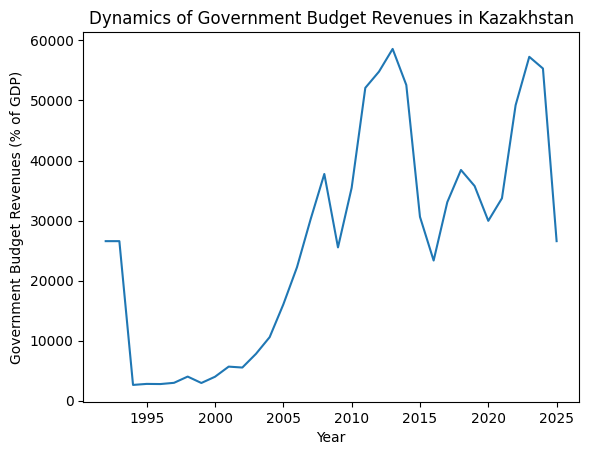

In [12]:
plt.figure()
plt.plot(df["Date"], df["Government Budget Revenues"])
plt.xlabel("Year")
plt.ylabel("Government Budget Revenues (% of GDP)")
plt.title("Dynamics of Government Budget Revenues in Kazakhstan")

### 6. Выберите объясняющую переменную, отвечающую за работу фискального правила. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

In [13]:
df["Oil Prices"].describe().round(3)

count     34.000
mean      66.891
std       23.623
min       24.460
25%       54.232
50%       66.890
75%       77.818
max      111.570
Name: Oil Prices, dtype: float64

Text(0.5, 1.0, 'Dynamics of Oil Prices in Kazakhstan')

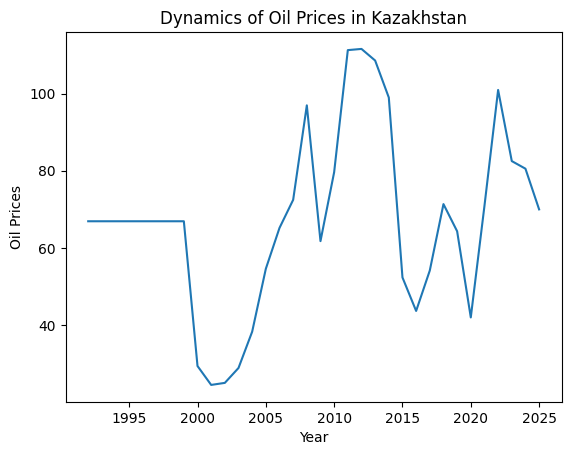

In [14]:
plt.figure()
plt.plot(df["Date"], df["Oil Prices"])
plt.xlabel("Year")
plt.ylabel("Oil Prices")
plt.title("Dynamics of Oil Prices in Kazakhstan")

### 7. Выберите контрольные переменные для Вашего исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранных переменных, опишите ее. Приведите ссылки на статистические источники.

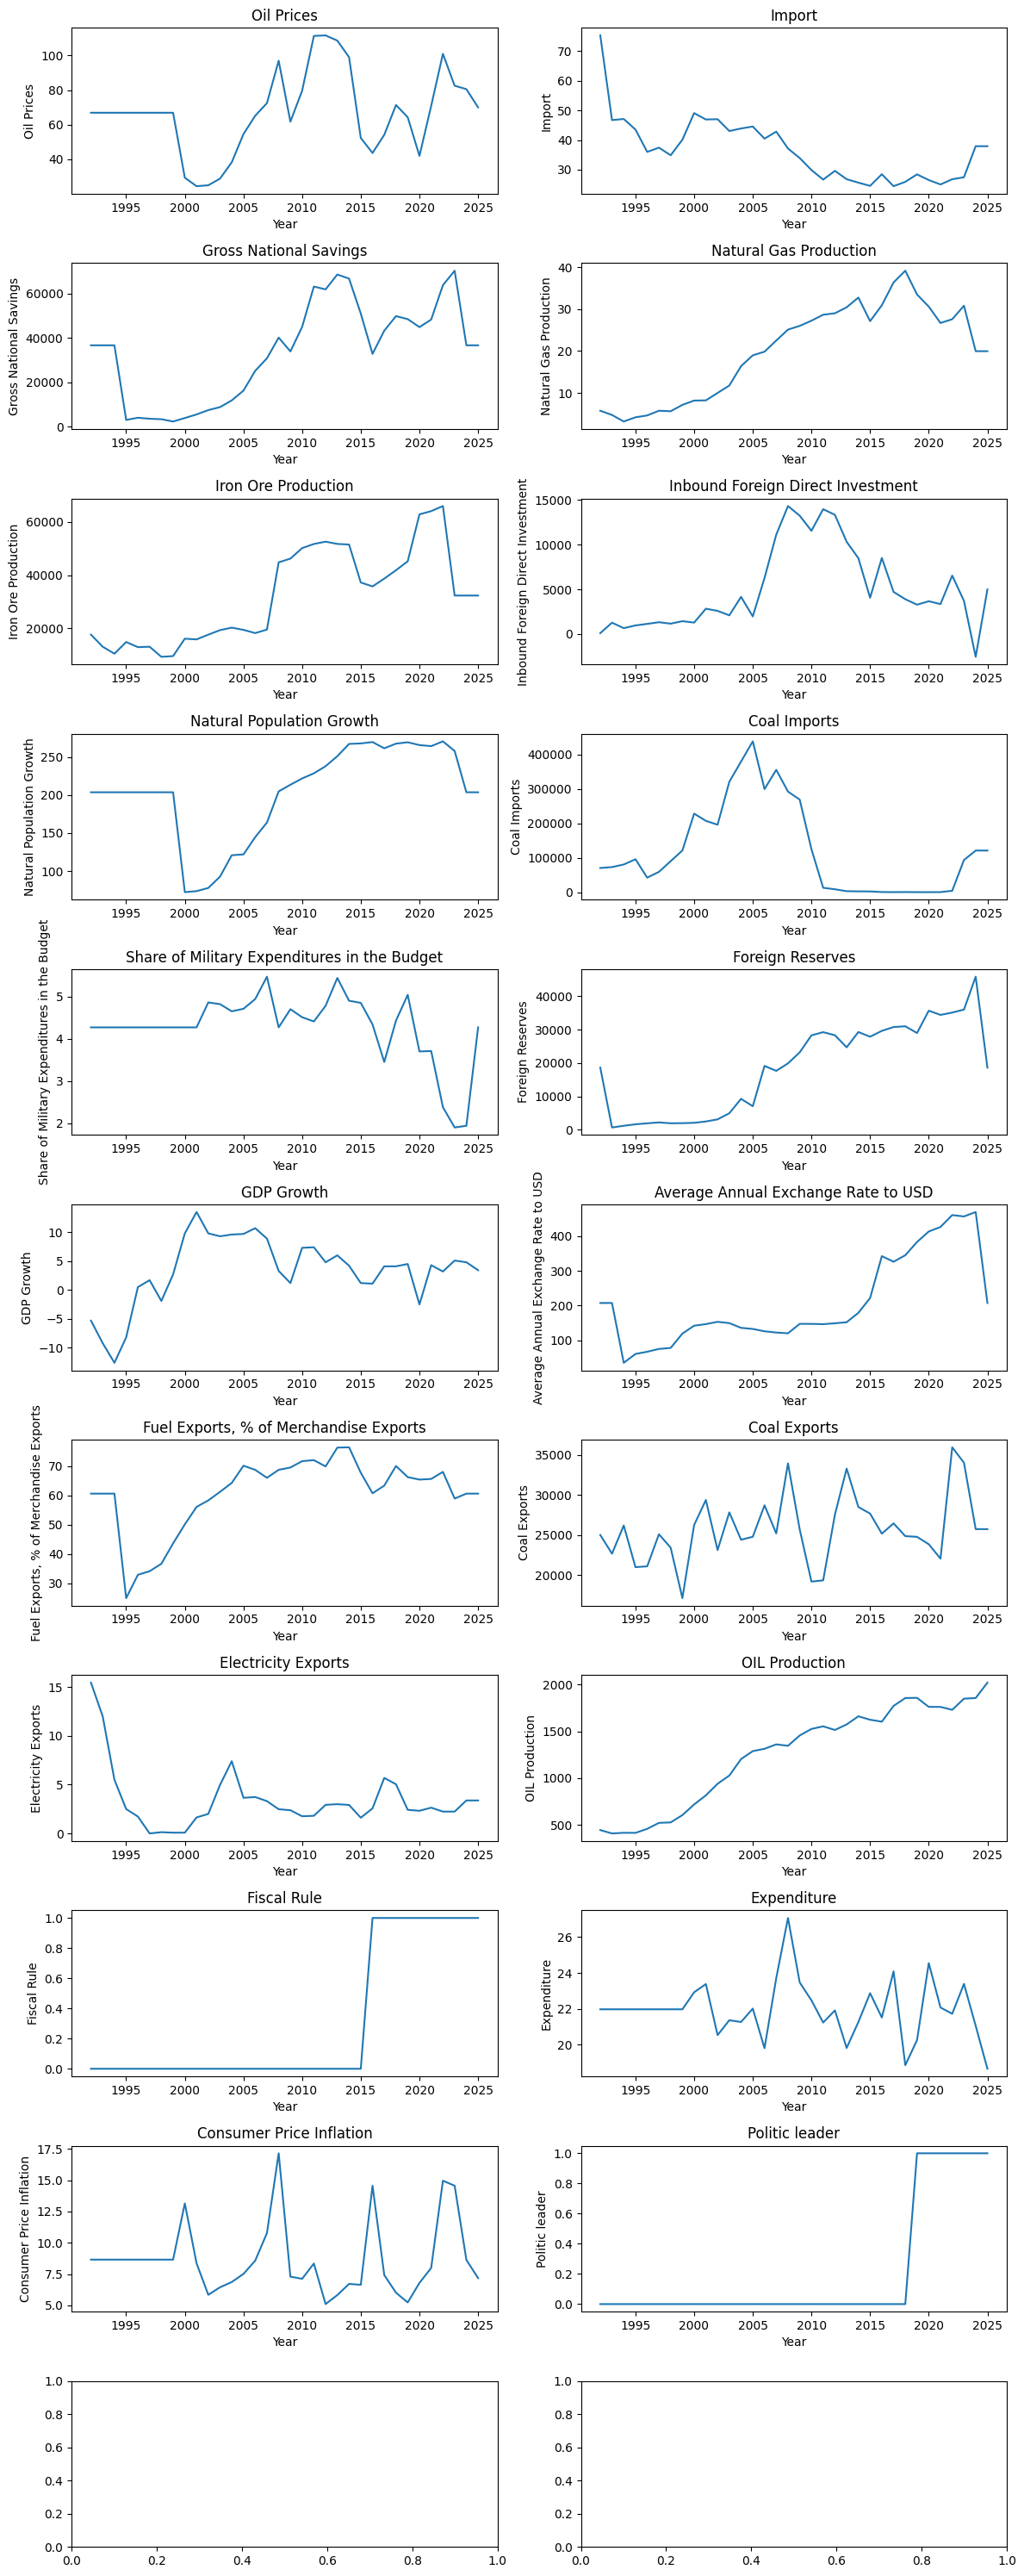

In [15]:
y = df["Government Budget Revenues"]   # новая целевая

vars_to_plot = [
    'Oil Prices',                 
    'Import',
    'Gross National Savings',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'GDP Growth',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Fiscal Rule',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader'
]

fig, axes = plt.subplots(11, 2, figsize=(12, 30))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    axes[i].plot(df["Date"], df[var])
    axes[i].set_title(var)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel(var)

plt.tight_layout()

### 8. Если Вы используете дамми-переменную в своем исследовании, опишите и обоснуйте.

### 9. Выпишите уравнение спецификации, которое Вы будете оценивать. В таблице опишите все основные описательные статистики выбранных переменных.

In [16]:
df.describe().round(2)

,Date,Import,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,2008.50,36.53,33569.52,16.18,19.97,31936.76,4994.21,203.48,26573.71,120972.59,4.27,18604.72,3.43,207.42,60.61,25723.62,3.38,1257.72,66.89,0.29,21.97,8.66,0.21
std,9.96,10.65,22108.82,5.08,11.16,17705.09,4545.76,61.39,18631.01,129956.72,0.82,13623.14,5.89,128.28,12.54,4220.62,3.11,533.55,23.62,0.46,1.62,2.93,0.41
min,1992.00,24.43,2313.00,6.68,3.18,9335.80,-2550.49,72.28,2637.00,21.00,1.90,711.00,-12.60,35.54,24.99,17097.98,0.00,408.00,24.46,0.00,18.65,5.11,0.00
25%,2000.25,26.96,9553.25,13.08,8.19,16535.35,1350.86,203.48,6216.50,3113.50,4.27,2664.75,1.20,127.79,59.35,23510.57,1.86,742.25,54.23,0.00,21.26,6.82,0.00
50%,2008.50,36.58,36673.91,15.84,21.24,32363.10,3691.76,203.48,26573.71,85266.00,4.27,19505.00,4.15,149.35,63.80,25170.53,2.54,1407.50,66.89,0.00,21.97,8.36,0.00
75%,2016.75,43.42,48426.50,19.82,28.93,45991.48,8002.58,260.38,37255.25,204502.50,4.76,29241.25,7.38,299.93,68.72,27631.72,3.58,1712.07,77.82,1.00,22.77,8.66,0.00
max,2025.00,75.33,70302.00,26.36,39.18,66000.00,14321.76,270.37,58577.00,438410.00,5.47,45808.00,13.50,468.96,76.39,35948.14,15.45,2019.86,111.57,1.00,27.07,17.15,1.00


### 10.  Используя МНК, эмпирически оцените коэффициенты Вашей модели. Результаты оценки представьте в тексте в адекватном и аккуратном виде. Вы обязаны скопировать результаты из используемой программы в Приложение! Без этого работа оценивается как 0. Проинтерпретируйте полученные результаты.

 # Как варик брать не все-все переменные, а с самой большой корреляцыей по модулю

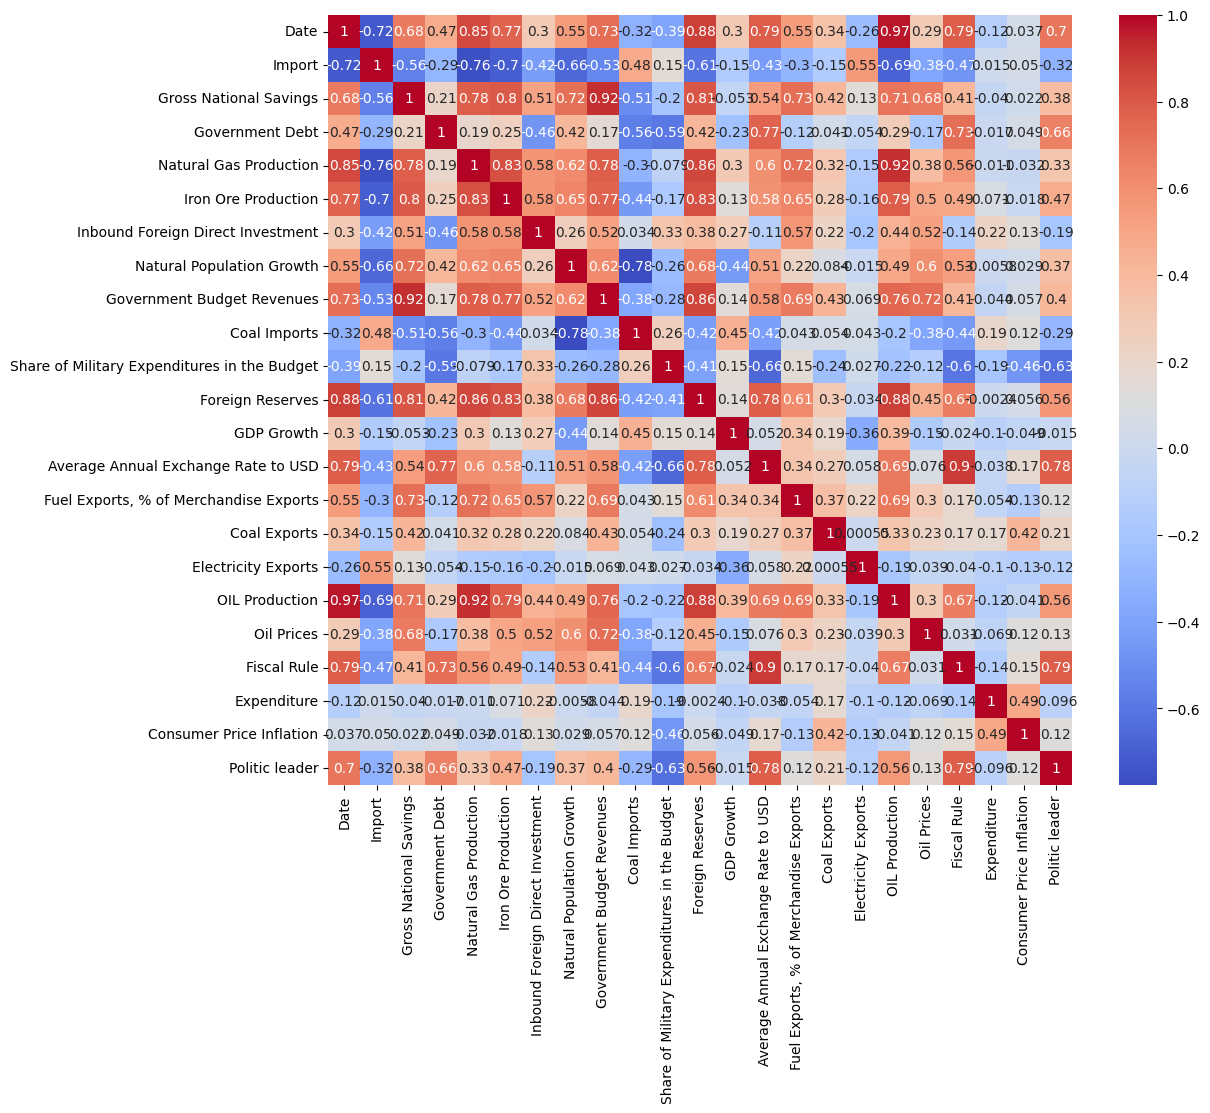

In [17]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## модель2- по макс абс корр

In [18]:
corr = df.corr(numeric_only=True)

target = "Government Budget Revenues"   # или любой другой столбец

top8 = corr[target].abs().sort_values(ascending=False).iloc[1:9]
top8

Gross National Savings                    0.921843
Foreign Reserves                          0.861418
Natural Gas Production                    0.780951
Iron Ore Production                       0.767583
OIL Production                            0.755381
Date                                      0.726436
Oil Prices                                0.723365
Fuel Exports, % of Merchandise Exports    0.685470
Name: Government Budget Revenues, dtype: float64

In [19]:
y = df["Government Budget Revenues"]   # целевая

X = df[[
    'Gross National Savings',
    'Foreign Reserves',
    'Natural Gas Production',
    'Iron Ore Production',
    'OIL Production',
    'Date',
    'Oil Prices',
    'Fuel Exports, % of Merchandise Exports'
]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     Government Budget Revenues   R-squared:                       0.935
Model:                                    OLS   Adj. R-squared:                  0.915
Method:                         Least Squares   F-statistic:                     45.20
Date:                        Sun, 30 Nov 2025   Prob (F-statistic):           5.71e-13
Time:                                09:10:54   Log-Likelihood:                -335.49
No. Observations:                          34   AIC:                             689.0
Df Residuals:                              25   BIC:                             702.7
Df Model:                                   8                                         
Covariance Type:                    nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                  -1.039e+05   1.56e+06     -0.066      0.948   -3.32e+06    3.12e+06
Gross National Savings                     0.2832      0.142      1.999      0.057      -0.009       0.575
Foreign Reserves                           0.5647      0.190      2.967      0.007       0.173       0.957
Natural Gas Production                   -86.1337    340.552     -0.253      0.802    -787.514     615.246
Iron Ore Production                       -0.1577      0.118     -1.339      0.192      -0.400       0.085
OIL Production                             3.6693     18.544      0.198      0.845     -34.524      41.862
Date                                      41.2815    783.269      0.053      0.958   -1571.891    1654.454
Oil Prices                               253.4991     67.974      3.729      0.001     113.504     393.494
Fuel Exports, % of Merchandise Exports   210.7846    222.802      0.946      0.353    -248.084     669.653
==============================================================================
Omnibus:                        9.807   Durbin-Watson:                   2.085
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               10.894
Skew:                          -0.781   Prob(JB):                      0.00431
Kurtosis:                       5.291   Cond. No.                     9.67e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.67e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
model.params.round(5)

const                                    -103944.07434
Gross National Savings                         0.28322
Foreign Reserves                               0.56467
Natural Gas Production                       -86.13375
Iron Ore Production                           -0.15771
OIL Production                                 3.66927
Date                                          41.28150
Oil Prices                                   253.49911
Fuel Exports, % of Merchandise Exports       210.78460
dtype: float64

In [21]:
p = model.pvalues

significant = [var for var in p.index if p[var] < 0.10]
nonsignificant = [var for var in p.index if p[var] >= 0.10]

print("Значимые переменные:", significant)
print("Незначимые переменные:", nonsignificant)


Значимые переменные: ['Gross National Savings', 'Foreign Reserves', 'Oil Prices']
Незначимые переменные: ['const', 'Natural Gas Production', 'Iron Ore Production', 'OIL Production', 'Date', 'Fuel Exports, % of Merchandise Exports']


также, построим 95% доверительные интервалы для всех коэффициентов:

In [22]:
conf = model.conf_int(alpha=0.05)

significant_ci = []
nonsignificant_ci = []

for var in conf.index:
    low, high = conf.loc[var]
    if low > 0 or high < 0:      # интервал не содержит ноль
        significant_ci.append(var)
    else:
        nonsignificant_ci.append(var)

print("Значимые по доверительным интервалам:", significant_ci)
print("Незначимые по доверительным интервалам:", nonsignificant_ci)

Значимые по доверительным интервалам: ['Foreign Reserves', 'Oil Prices']
Незначимые по доверительным интервалам: ['const', 'Gross National Savings', 'Natural Gas Production', 'Iron Ore Production', 'OIL Production', 'Date', 'Fuel Exports, % of Merchandise Exports']


### 11.  Проведите проверку результатов на устойчивость. Метод Вы выбираете сами. Устойчивы ли Ваши результаты?

#### 1 способ: Робастные стандартные ошибки (HC3)

In [23]:
model_robust = model.get_robustcov_results(cov_type="HC3")

p = model_robust.pvalues
names = model_robust.model.exog_names

significant = [names[i] for i in range(len(p)) if p[i] < 0.10]
nonsignificant = [names[i] for i in range(len(p)) if p[i] >= 0.10]

print("Значимые (robust):", significant)
print("Незначимые (robust):", nonsignificant)

Значимые (robust): ['Oil Prices']
Незначимые (robust): ['const', 'Gross National Savings', 'Foreign Reserves', 'Natural Gas Production', 'Iron Ore Production', 'OIL Production', 'Date', 'Fuel Exports, % of Merchandise Exports']


#### 2 способ: Мультиколлинеарность (VIF)

In [27]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.round(2)

,Variable,VIF
0,const,2805938.08
1,Gross National Savings,10.92
2,Foreign Reserves,7.49
3,Natural Gas Production,16.09
4,Iron Ore Production,4.84
5,OIL Production,109.04
6,Date,67.76
7,Oil Prices,2.87
8,"Fuel Exports, % of Merchandise Exports",8.70


#### 3 способ: оценка модели на части признаков. (Leave-one-out robustness check)

Мы проверяем, насколько чувствительны результаты модели к выбору набора регрессоров. Для этого по очереди исключаем из модели каждую объясняющую переменную, заново оцениваем регрессию и смотрим, как изменяется коэффициент при ключевой переменной FiscalRule. Если коэффициент остаётся примерно таким же, значит модель устойчива к спецификации; если изменяется резко, значит зависимость чувствительна к исключению этой переменной.

Этот метод широко используется как тест устойчивости результатов (robustness to model specification).

In [25]:
y = df["Government Budget Revenues"]   # новая зависимая

control_vars = [
    'Gross National Savings',
    'Foreign Reserves',
    'Natural Gas Production',
    'Iron Ore Production',
    'OIL Production',
    'Date',
    'Fuel Exports, % of Merchandise Exports'
]

results = []

for var in control_vars:
    vars_subset = [v for v in control_vars if v != var]
    model = sm.OLS(y, sm.add_constant(df[vars_subset + ["Oil Prices"]])).fit()
    coef = model.params.get("Oil Prices", None)
    results.append([var, coef])

pd.DataFrame(results, columns=["Removed variable", "OilPrices coefficient"])

,Removed variable,OilPrices coefficient
0,Gross National Savings,347.785907
1,Foreign Reserves,254.680054
2,Natural Gas Production,258.898699
3,Iron Ore Production,230.734718
4,OIL Production,258.490601
5,Date,252.027564
6,"Fuel Exports, % of Merchandise Exports",221.667650


### 12.  Постройте прогноз, используя Вашу оцененную модель. Результаты представьте на графике. Опишите его и проинтерпретируйте.

прогноз по 3-летнему скользящему среднему (MA-3) и подстановка результата OLS-модель.

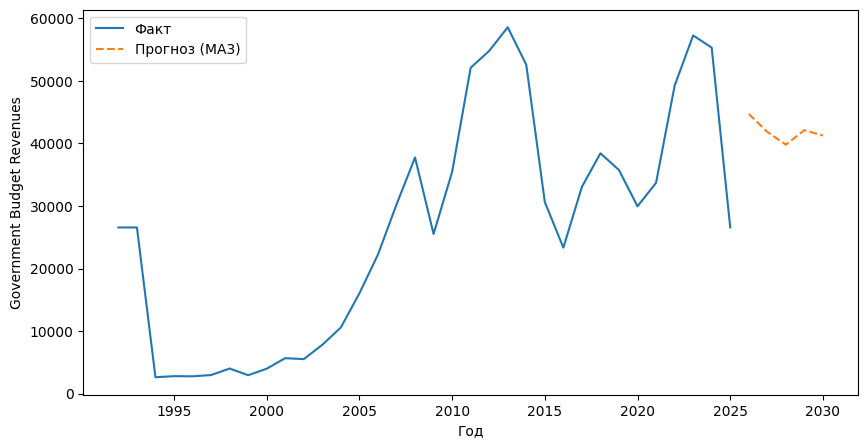

In [26]:
X_vars = [
    'Gross National Savings',
    'Foreign Reserves',
    'Natural Gas Production',
    'Iron Ore Production',
    'OIL Production',
    'Date',
    'Fuel Exports, % of Merchandise Exports',
    'Oil Prices'
]

future_years = [2026, 2027, 2028, 2029, 2030]

X_extended = df[X_vars].copy()

for year in future_years:
    ma3 = X_extended.tail(3).mean()
    X_extended.loc[year] = ma3

X_future = X_extended.loc[future_years].copy()
X_future["const"] = 1
X_future = X_future[model.model.exog_names]

forecast_ma = model.predict(X_future)

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Government Budget Revenues"], label="Факт")
plt.plot(forecast_ma.index, forecast_ma.values, label="Прогноз (MA3)", linestyle="--")
plt.xlabel("Год")
plt.ylabel("Government Budget Revenues")
plt.legend()
plt.show()
